In [34]:
import skimage as ski
print(ski.__version__)

0.26.0


In [35]:
import skimage as ski

In [36]:
camera = ski.data.camera()

In [37]:
type(camera)

numpy.ndarray

In [38]:
camera.shape

(512, 512)

In [39]:
coins = ski.data.coins()
threshold_value = ski.filters.threshold_otsu(coins)
threshold_value

np.int64(107)

In [40]:
import matplotlib.pyplot as plt
import matplotlib

import skimage as ski

matplotlib.rcParams["font.size"] = 18

In [64]:
import os
import skimage as ski
filename = os.path.join(ski.data_dir, "moon.png")
moon = ski.io.imread(filename)

FileNotFoundError: No such file: '/Users/azharul/Library/Caches/scikit-image/0.26.0/data/moon.png'

In [65]:
import imageio.v3 as iio3
from sklearn.datasets import make_moons
filename = os.path.join(ski.data_dir, 'moon.png')
moon = iio3.imread(filename)

FileNotFoundError: No such file: '/Users/azharul/Library/Caches/scikit-image/0.26.0/data/moon.png'

In [43]:
import os
from natsort import natsorted, ns
list_files = os.listdir('.')
list_files

['Pandas_practice.ipynb',
 '.DS_Store',
 'anaconda_projects',
 'sklearn_image.ipynb',
 'Python Practice 1.ipynb',
 'air_quality_long.csv',
 'Numjpy_practice.ipynb',
 'tensorflow.ipynb',
 '.ipynb_checkpoints',
 'data']

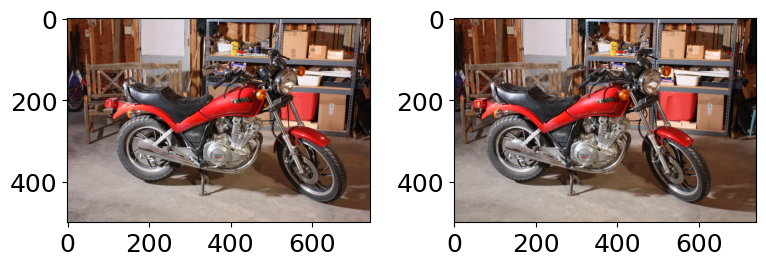

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
ax = axes.ravel()

cycle_images = ski.data.stereo_motorcycle()
ax[0].imshow(cycle_images[0])
ax[1].imshow(cycle_images[1])

fig.tight_layout()
plt.show()

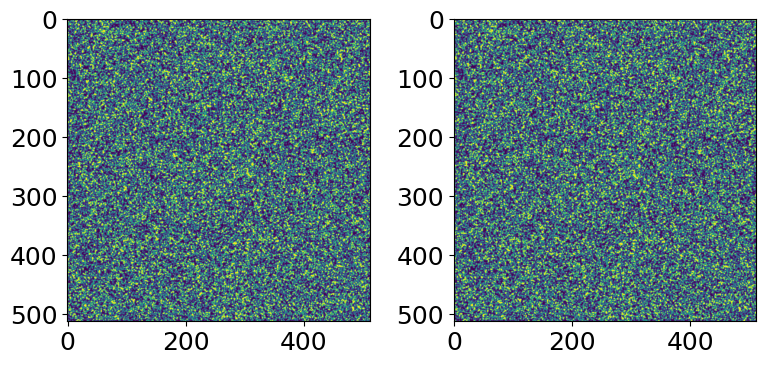

In [45]:
fig, axes = plt.subplots(ncols=2, figsize=(8, 4))
ax = axes.ravel()

vortex_images = ski.data.vortex()
ax[0].imshow(vortex_images[0])
ax[1].imshow(vortex_images[1])

fig.tight_layout()
plt.show()

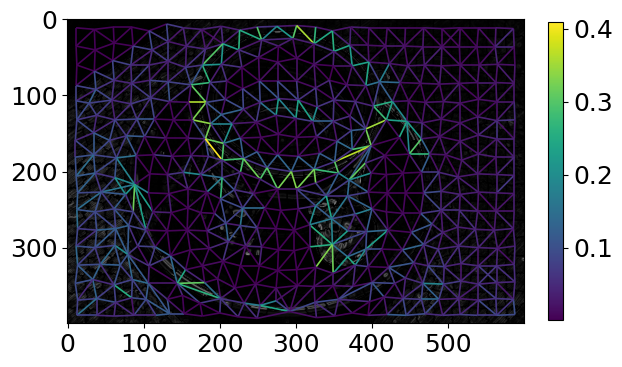

In [46]:
from skimage import graph
from skimage import data, segmentation, color, filters
from matplotlib import pyplot as plt


img = data.coffee()
gimg = color.rgb2gray(img)

labels = segmentation.slic(img, compactness=30, n_segments=400, start_label=1)
edges = filters.sobel(gimg)
edges_rgb = color.gray2rgb(edges)

fig, ax = plt.subplots()

g = graph.rag_boundary(labels, edges)
lc = graph.show_rag(
    labels, g, edges_rgb, img_cmap=None, ax=ax, edge_cmap='viridis', edge_width=1.2
)


plt.colorbar(lc, fraction=0.03)
plt.show()

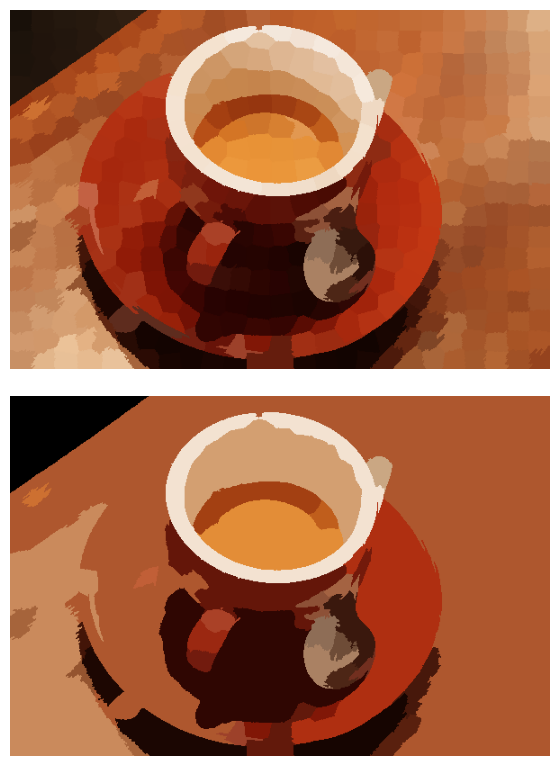

In [47]:
from skimage import data, segmentation, color
from skimage import graph
from matplotlib import pyplot as plt


img = data.coffee()

labels1 = segmentation.slic(img, compactness=30, n_segments=400, start_label=1)
out1 = color.label2rgb(labels1, img, kind='avg', bg_label=0)

g = graph.rag_mean_color(img, labels1)
labels2 = graph.cut_threshold(labels1, g, 29)
out2 = color.label2rgb(labels2, img, kind='avg', bg_label=0)

fig, ax = plt.subplots(nrows=2, sharex=True, sharey=True, figsize=(6, 8))

ax[0].imshow(out1)
ax[1].imshow(out2)

for a in ax:
    a.axis('off')

plt.tight_layout()

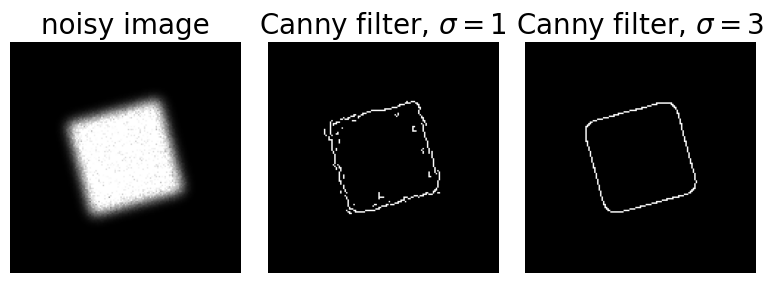

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage.util import random_noise
from skimage import feature


# Generate noisy image of a square
image = np.zeros((128, 128), dtype=float)
image[32:-32, 32:-32] = 1

image = ndi.rotate(image, 15, mode='constant')
image = ndi.gaussian_filter(image, 4)
image = random_noise(image, mode='speckle', mean=0.1)

# Compute the Canny filter for two values of sigma
edges1 = feature.canny(image)
edges2 = feature.canny(image, sigma=3)

# display results
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(8, 3))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('noisy image', fontsize=20)

ax[1].imshow(edges1, cmap='gray')
ax[1].set_title(r'Canny filter, $\sigma=1$', fontsize=20)

ax[2].imshow(edges2, cmap='gray')
ax[2].set_title(r'Canny filter, $\sigma=3$', fontsize=20)

for a in ax:
    a.axis('off')

fig.tight_layout()
plt.show()

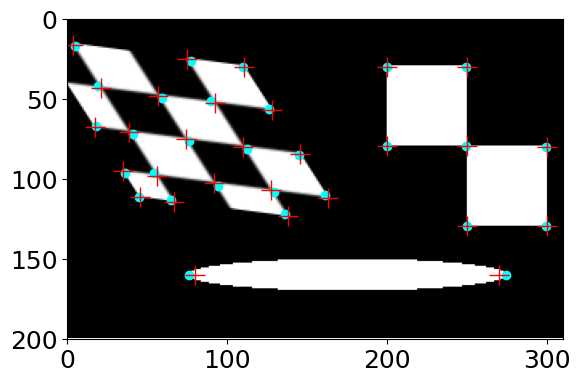

In [49]:
from matplotlib import pyplot as plt

from skimage import data
from skimage.feature import corner_harris, corner_subpix, corner_peaks
from skimage.transform import warp, AffineTransform
from skimage.draw import ellipse

# Sheared checkerboard
tform = AffineTransform(scale=(1.3, 1.1), rotation=1, shear=0.7, translation=(110, 30))
image = warp(data.checkerboard()[:90, :90], tform.inverse, output_shape=(200, 310))
# Ellipse
rr, cc = ellipse(160, 175, 10, 100)
image[rr, cc] = 1
# Two squares
image[30:80, 200:250] = 1
image[80:130, 250:300] = 1

coords = corner_peaks(corner_harris(image), min_distance=5, threshold_rel=0.02)
coords_subpix = corner_subpix(image, coords, window_size=13)

fig, ax = plt.subplots()
ax.imshow(image, cmap=plt.cm.gray)
ax.plot(
    coords[:, 1], coords[:, 0], color='cyan', marker='o', linestyle='None', markersize=6
)
ax.plot(coords_subpix[:, 1], coords_subpix[:, 0], '+r', markersize=15)
ax.axis((0, 310, 200, 0))
plt.show()

In [57]:
import sys
import cv2 as cv
import numpy as np 

#  Global Variables

DELAY_CAPTION = 1500
DELAY_BLUR = 100
MAX_KERNEL_LENGTH = 31

src = None
dst = None
window_name = 'Smoothing Demo'

def main(argv):
    cv.namedWindow(window_name, cv.WINDOW_AUTOSIZE)

    # Load the source image
    imageName = argv[0] if len(argv) > 0 else 'lena.jpg'

    global src
    src = cv.imread(cv.samples.findFile(imageName))
    if src is None:
        print ('Error opening image')
        print ('Usage: smoothing.py [image_name -- default ../data/lena.jpg] \n')
        return -1

    if display_caption('Original Image') != 0:
        return 0

    global dst
    dst = np.copy(src)
    if display_dst(DELAY_CAPTION) != 0:
        return 0

    # Applying Homogeneous blur
    if display_caption('Homogeneous Blur') != 0:
        return 0

    for i in range(1, MAX_KERNEL_LENGTH, 2):
        dst = cv.blur(src, (i, i))
        if display_dst(DELAY_BLUR) != 0:
            return 0

    # Applying Gaussian blur
    if display_caption('Gaussian Blur') != 0:
        return 0

    for i in range(1, MAX_KERNEL_LENGTH, 2):
        dst = cv.GaussianBlur(src, (i, i), 0)
        if display_dst(DELAY_BLUR) != 0:
            return 0

    # Applying Median blur
    if display_caption('Median Blur') != 0:
        return 0

    for i in range(1, MAX_KERNEL_LENGTH, 2):
        dst = cv.medianBlur(src, i)
        if display_dst(DELAY_BLUR) != 0:
            return 0

    # Applying Bilateral Filter
    if display_caption('Bilateral Blur') != 0:
        return 0

    for i in range(1, MAX_KERNEL_LENGTH, 2):
        dst = cv.bilateralFilter(src, i, i * 2, i / 2)
        if display_dst(DELAY_BLUR) != 0:
            return 0

    #  Done
    display_caption('Done!')

    return 0

def display_caption(caption):
    global dst
    dst = np.zeros(src.shape, src.dtype)
    rows, cols, _ch = src.shape
    cv.putText(dst, caption,
                (int(cols / 4), int(rows / 2)),
                cv.FONT_HERSHEY_COMPLEX, 1, (255, 255, 255))

    return display_dst(DELAY_CAPTION)

def display_dst(delay):
    cv.imshow(window_name, dst)
    c = cv.waitKey(delay)
    if c >= 0 : return -1
    return 0

if __name__ == "__main__":
    main(sys.argv[1:])

[ WARN:0@2066.424] global samples.cpp:61 findFile cv::samples::findFile('-f') => ''


error: OpenCV(4.13.0) /Users/xperience/GHA-OpenCV-Python/_work/opencv-python/opencv-python/opencv/modules/core/src/utils/samples.cpp:64: error: (-2:Unspecified error) OpenCV samples: Can't find required data file: -f in function 'findFile'


In [51]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skimage.draw import ellipse
from skimage.measure import label, regionprops, regionprops_table
from skimage.transform import rotate


image = np.zeros((600, 600))

rr, cc = ellipse(300, 350, 100, 220)
image[rr, cc] = 1

image = rotate(image, angle=15, order=0)

rr, cc = ellipse(100, 100, 60, 50)
image[rr, cc] = 1

label_img = label(image)
regions = regionprops(label_img)

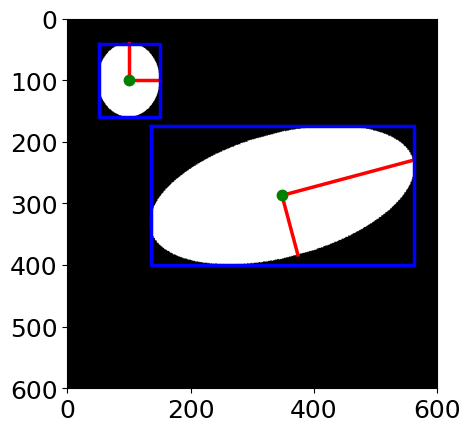

In [52]:
fig, ax = plt.subplots()
ax.imshow(image, cmap=plt.cm.gray)

for props in regions:
    y0, x0 = props.centroid
    orientation = props.orientation
    x1 = x0 + math.cos(orientation) * 0.5 * props.axis_minor_length
    y1 = y0 - math.sin(orientation) * 0.5 * props.axis_minor_length
    x2 = x0 - math.sin(orientation) * 0.5 * props.axis_major_length
    y2 = y0 - math.cos(orientation) * 0.5 * props.axis_major_length

    ax.plot((x0, x1), (y0, y1), '-r', linewidth=2.5)
    ax.plot((x0, x2), (y0, y2), '-r', linewidth=2.5)
    ax.plot(x0, y0, '.g', markersize=15)

    minr, minc, maxr, maxc = props.bbox
    bx = (minc, maxc, maxc, minc, minc)
    by = (minr, minr, maxr, maxr, minr)
    ax.plot(bx, by, '-b', linewidth=2.5)

ax.axis((0, 600, 600, 0))
plt.show()

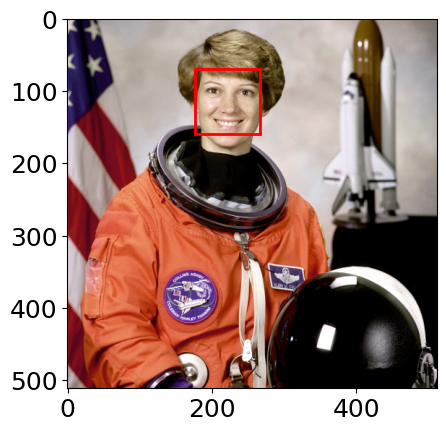

In [53]:
import skimage as ski

import matplotlib.pyplot as plt
from matplotlib import patches

# Load the trained file from the module root.
trained_file = ski.data.lbp_frontal_face_cascade_filename()

# Initialize the detector cascade.
detector = ski.feature.Cascade(trained_file)

img = ski.data.astronaut()

detected = detector.detect_multi_scale(
    img=img, scale_factor=1.2, step_ratio=1, min_size=(60, 60), max_size=(123, 123)
)

fig, ax = plt.subplots()
ax.imshow(img, cmap='gray')

for patch in detected:
    ax.axes.add_patch(
        patches.Rectangle(
            (patch['c'], patch['r']),
            patch['width'],
            patch['height'],
            fill=False,
            color='r',
            linewidth=2,
        )
    )

plt.show()

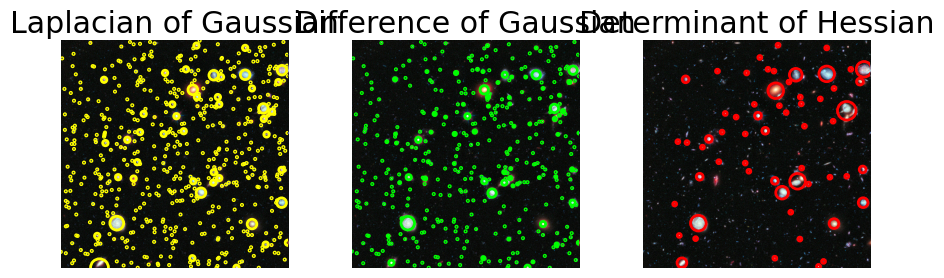

In [54]:
from math import sqrt
from skimage import data
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.color import rgb2gray

import matplotlib.pyplot as plt


image = data.hubble_deep_field()[0:500, 0:500]
image_gray = rgb2gray(image)

blobs_log = blob_log(image_gray, max_sigma=30, num_sigma=10, threshold=0.1)

# Compute radii in the 3rd column.
blobs_log[:, 2] = blobs_log[:, 2] * sqrt(2)

blobs_dog = blob_dog(image_gray, max_sigma=30, threshold=0.1)
blobs_dog[:, 2] = blobs_dog[:, 2] * sqrt(2)

blobs_doh = blob_doh(image_gray, max_sigma=30, threshold=0.01)

blobs_list = [blobs_log, blobs_dog, blobs_doh]
colors = ['yellow', 'lime', 'red']
titles = ['Laplacian of Gaussian', 'Difference of Gaussian', 'Determinant of Hessian']
sequence = zip(blobs_list, colors, titles)

fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True)
ax = axes.ravel()

for idx, (blobs, color, title) in enumerate(sequence):
    ax[idx].set_title(title)
    ax[idx].imshow(image)
    for blob in blobs:
        y, x, r = blob
        c = plt.Circle((x, y), r, color=color, linewidth=2, fill=False)
        ax[idx].add_patch(c)
    ax[idx].set_axis_off()

plt.tight_layout()
plt.show()

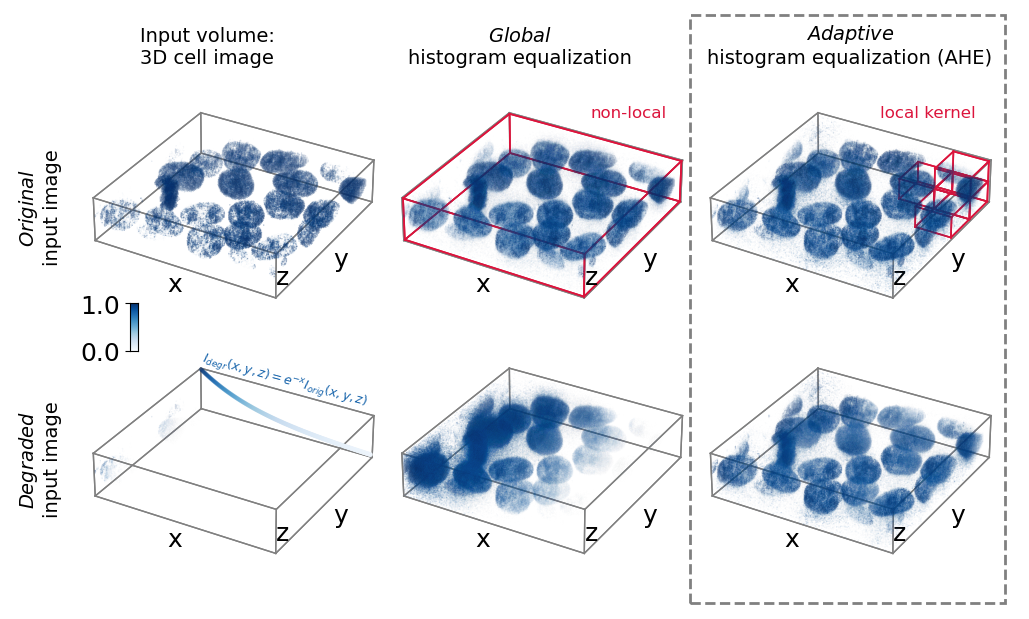

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import cm, colors
from mpl_toolkits.mplot3d import Axes3D

import numpy as np
from skimage import exposure, util


# Prepare data and apply histogram equalization

from skimage.data import cells3d

im_orig = util.img_as_float(cells3d()[:, 1, :, :])  # grab just the nuclei

# Reorder axis order from (z, y, x) to (x, y, z)
im_orig = im_orig.transpose()

# Rescale image data to range [0, 1]
im_orig = np.clip(im_orig, np.percentile(im_orig, 5), np.percentile(im_orig, 95))
im_orig = (im_orig - im_orig.min()) / (im_orig.max() - im_orig.min())

# Degrade image by applying exponential intensity decay along x
sigmoid = np.exp(-3 * np.linspace(0, 1, im_orig.shape[0]))
im_degraded = (im_orig.T * sigmoid).T

# Set parameters for AHE
# Determine kernel sizes in each dim relative to image shape
kernel_size = (im_orig.shape[0] // 5, im_orig.shape[1] // 5, im_orig.shape[2] // 2)
kernel_size = np.array(kernel_size)
clip_limit = 0.9

# Perform histogram equalization
im_orig_he, im_degraded_he = (
    exposure.equalize_hist(im) for im in [im_orig, im_degraded]
)

im_orig_ahe, im_degraded_ahe = (
    exposure.equalize_adapthist(im, kernel_size=kernel_size, clip_limit=clip_limit)
    for im in [im_orig, im_degraded]
)


# Define functions to help plot the data


def scalars_to_rgba(scalars, cmap, vmin=0.0, vmax=1.0, alpha=0.2):
    """
    Convert array of scalars into array of corresponding RGBA values.
    """
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    scalar_map = cm.ScalarMappable(norm=norm, cmap=cmap)
    rgbas = scalar_map.to_rgba(scalars)
    rgbas[:, 3] = alpha
    return rgbas


def plt_render_volume(vol, fig_ax, cmap, vmin=0, vmax=1, bin_widths=None, n_levels=20):
    """
    Render a volume in a 3D matplotlib scatter plot.
    Better would be to use napari.
    """
    vol = np.clip(vol, vmin, vmax)

    xs, ys, zs = np.mgrid[
        0 : vol.shape[0] : bin_widths[0],
        0 : vol.shape[1] : bin_widths[1],
        0 : vol.shape[2] : bin_widths[2],
    ]
    vol_scaled = vol[:: bin_widths[0], :: bin_widths[1], :: bin_widths[2]].flatten()

    # Define alpha transfer function
    levels = np.linspace(vmin, vmax, n_levels)
    alphas = np.linspace(0, 0.7, n_levels)
    alphas = alphas**11
    alphas = (alphas - alphas.min()) / (alphas.max() - alphas.min())
    alphas *= 0.8

    # Group pixels by intensity and plot separately,
    # as 3D scatter does not accept arrays of alpha values
    for il in range(1, len(levels)):
        sel = vol_scaled >= levels[il - 1]
        sel *= vol_scaled <= levels[il]
        if not np.max(sel):
            continue
        c = scalars_to_rgba(
            vol_scaled[sel], cmap, vmin=vmin, vmax=vmax, alpha=alphas[il - 1]
        )
        fig_ax.scatter(
            xs.flatten()[sel],
            ys.flatten()[sel],
            zs.flatten()[sel],
            c=c,
            s=0.5 * np.mean(bin_widths),
            marker='o',
            linewidth=0,
        )


# Create figure with subplots

cmap = 'Blues'

fig = plt.figure(figsize=(10, 6))
axs = [
    fig.add_subplot(2, 3, i + 1, projection=Axes3D.name, facecolor="none")
    for i in range(6)
]
ims = [im_orig, im_orig_he, im_orig_ahe, im_degraded, im_degraded_he, im_degraded_ahe]

# Prepare lines for the various boxes to be plotted
verts = np.array([[i, j, k] for i in [0, 1] for j in [0, 1] for k in [0, 1]]).astype(
    np.float32
)
lines = [
    np.array([i, j])
    for i in verts
    for j in verts
    if np.allclose(np.linalg.norm(i - j), 1)
]

# "render" volumetric data
for iax, ax in enumerate(axs[:]):
    plt_render_volume(ims[iax], ax, cmap, 0, 1, [2, 2, 2], 20)

    # plot 3D box
    rect_shape = np.array(im_orig.shape) + 2
    for line in lines:
        ax.plot(
            (line * rect_shape)[:, 0] - 1,
            (line * rect_shape)[:, 1] - 1,
            (line * rect_shape)[:, 2] - 1,
            linewidth=1,
            color='gray',
        )

# Add boxes illustrating the kernels
ns = np.array(im_orig.shape) // kernel_size - 1
for axis_ind, vertex_ind, box_shape in zip(
    [1] + [2] * 4,
    [
        [0, 0, 0],
        [ns[0] - 1, ns[1], ns[2] - 1],
        [ns[0], ns[1] - 1, ns[2] - 1],
        [ns[0], ns[1], ns[2] - 1],
        [ns[0], ns[1], ns[2]],
    ],
    [np.array(im_orig.shape)] + [kernel_size] * 4,
):
    for line in lines:
        axs[axis_ind].plot(
            ((line + vertex_ind) * box_shape)[:, 0],
            ((line + vertex_ind) * box_shape)[:, 1],
            ((line + vertex_ind) * box_shape)[:, 2],
            linewidth=1.2,
            color='crimson',
        )

# Plot degradation function
axs[3].scatter(
    xs=np.arange(len(sigmoid)),
    ys=np.zeros(len(sigmoid)) + im_orig.shape[1],
    zs=sigmoid * im_orig.shape[2],
    s=5,
    c=scalars_to_rgba(sigmoid, cmap=cmap, vmin=0, vmax=1, alpha=1.0)[:, :3],
)

# Subplot aesthetics
for iax, ax in enumerate(axs[:]):
    # Get rid of panes and axis lines
    for dim_ax in [ax.xaxis, ax.yaxis, ax.zaxis]:
        dim_ax.set_pane_color((1.0, 1.0, 1.0, 0.0))
        dim_ax.line.set_color((1.0, 1.0, 1.0, 0.0))

    # Define 3D axes limits, see https://github.com/
    # matplotlib/matplotlib/issues/17172#issuecomment-617546105
    xyzlim = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()]).T
    XYZlim = np.asarray([min(xyzlim[0]), max(xyzlim[1])])
    ax.set_xlim3d(XYZlim)
    ax.set_ylim3d(XYZlim)
    ax.set_zlim3d(XYZlim * 0.5)

    try:
        ax.set_aspect('equal')
    except NotImplementedError:
        pass

    ax.set_xlabel('x', labelpad=-20)
    ax.set_ylabel('y', labelpad=-20)
    ax.text2D(0.63, 0.2, "z", transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.grid(False)
    ax.elev = 30

plt.subplots_adjust(
    left=0.05, bottom=-0.1, right=1.01, top=1.1, wspace=-0.1, hspace=-0.45
)

# Highlight AHE
rect_ax = fig.add_axes([0, 0, 1, 1], facecolor='none')
rect_ax.set_axis_off()
rect = patches.Rectangle(
    (0.68, 0.01),
    0.315,
    0.98,
    edgecolor='gray',
    facecolor='none',
    linewidth=2,
    linestyle='--',
)
rect_ax.add_patch(rect)

# Add text
rect_ax.text(
    0.19,
    0.34,
    '$I_{degr}(x,y,z) = e^{-x}I_{orig}(x,y,z)$',
    fontsize=9,
    rotation=-15,
    color=scalars_to_rgba([0.8], cmap='Blues', alpha=1.0)[0],
)

fc = {'size': 14}
rect_ax.text(
    0.03,
    0.58,
    r'$\it{Original}$' + '\ninput image',
    rotation=90,
    fontdict=fc,
    horizontalalignment='center',
)
rect_ax.text(
    0.03,
    0.16,
    r'$\it{Degraded}$' + '\ninput image',
    rotation=90,
    fontdict=fc,
    horizontalalignment='center',
)
rect_ax.text(0.13, 0.91, 'Input volume:\n3D cell image', fontdict=fc)
rect_ax.text(
    0.51,
    0.91,
    r'$\it{Global}$' + '\nhistogram equalization',
    fontdict=fc,
    horizontalalignment='center',
)
rect_ax.text(
    0.84,
    0.91,
    r'$\it{Adaptive}$' + '\nhistogram equalization (AHE)',
    fontdict=fc,
    horizontalalignment='center',
)
rect_ax.text(0.58, 0.82, 'non-local', fontsize=12, color='crimson')
rect_ax.text(0.87, 0.82, 'local kernel', fontsize=12, color='crimson')

# Add colorbar
cbar_ax = fig.add_axes([0.12, 0.43, 0.008, 0.08])
cbar_ax.imshow(np.arange(256).reshape(256, 1)[::-1], cmap=cmap, aspect="auto")
cbar_ax.set_xticks([])
cbar_ax.set_yticks([0, 255])
cbar_ax.set_xticklabels([])
cbar_ax.set_yticklabels([1.0, 0.0])

plt.show()